In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

In [4]:
from scipy.spatial.distance import pdist, squareform

# IMPORT DATASETS

In [5]:
stores   = pd.read_csv("data/saigon_bean_stores.csv")
products = pd.read_csv("data/saigon_bean_products.csv")
tx       = pd.read_csv("data/saigon_bean_transactions.csv")

In [16]:
stores.describe()

,store_id,seats
count,12.000000,12.000000
mean,6.500000,42.833333
std,3.605551,16.235950
min,1.000000,16.000000
25%,3.750000,31.500000
50%,6.500000,42.000000
75%,9.250000,55.000000
max,12.000000,70.000000


In [17]:
products.describe()

,product_id,list_price
count,17.000000,17.000000
mean,208.882353,62911.764706
std,107.953626,50514.922082
min,101.000000,25000.000000
25%,105.000000,42000.000000
50%,202.000000,45000.000000
75%,302.000000,55000.000000
max,402.000000,220000.000000


In [18]:
tx.describe()

,order_id,store_id,customer_id,product_id,quantity,unit_price,discount,line_total
count,97239.000000,97239.000000,63670.000000,97239.000000,97239.000000,9.723900e+04,97239.000000,9.723900e+04
mean,525130.757237,5.525170,11870.590969,180.697436,1.243277,4.637437e+04,0.009830,5.719694e+04
std,14627.909577,3.617548,1414.879081,87.004732,0.431286,4.950550e+04,0.038543,7.897255e+04
min,500001.000000,1.000000,10001.000000,101.000000,-2.000000,2.500000e+04,0.000000,-1.180000e+05
25%,512462.000000,2.000000,10685.000000,103.000000,1.000000,3.900000e+04,0.000000,4.420000e+04
50%,525015.000000,5.000000,11362.000000,107.000000,1.000000,4.500000e+04,0.000000,5.200000e+04
75%,537723.000000,9.000000,13071.000000,301.000000,1.000000,5.200000e+04,0.000000,5.900000e+04
max,551108.000000,12.000000,14800.000000,402.000000,2.000000,5.500000e+06,0.200000,1.100000e+07


In [6]:
print("stores:", stores.shape, "| products:", products.shape, "| transactions:", tx.shape)

df = (tx.merge(stores,   on="store_id",   how="left", validate="m:1")
        .merge(products, on="product_id", how="left", validate="m:1"))

print("Shape after joins:", df.shape)
df.head()

stores: (12, 5) | products: (17, 4) | transactions: (97239, 10)
Shape after joins: (97239, 17)


,order_id,store_id,order_time,channel,customer_id,product_id,quantity,unit_price,discount,line_total,store_name,district,store_type,seats,product_name,category,list_price
0,519273,4,6/1/2026 7:00,delivery,NaN,101,1,45000,0.0,45000,Vincom Dong Khoi,District 1,mall,54,Vietnamese Iced Milk Coffee,coffee,45000
1,519273,4,6/1/2026 7:00,delivery,NaN,301,1,31500,0.0,31500,Vincom Dong Khoi,District 1,mall,54,Butter Croissant,pastry,31500
2,524107,5,6/1/2026 7:06,in-store,12417.0,103,1,52000,0.0,52000,Crescent Mall,District 7,mall,48,Latte,coffee,52000
3,500071,1,6/1/2026 7:07,in-store,NaN,201,2,45000,0.0,90000,Nguyen Hue,District 1,mall,70,Peach Tea,tea,45000
4,500071,1,6/1/2026 7:07,in-store,NaN,202,2,42000,0.0,84000,Nguyen Hue,District 1,mall,70,Lotus Tea,tea,42000


In [7]:
attr = pd.DataFrame([
    ("order_id","Nominal (identifier)"), ("store_id","Nominal (identifier)"),
    ("order_time","Interval (date-time)"), ("channel","Nominal"),
    ("customer_id","Nominal (identifier)"), ("product_id","Nominal (identifier)"),
    ("quantity","Ratio (discrete)"), ("unit_price","Ratio (continuous)"),
    ("discount","Ratio (continuous)"), ("line_total","Ratio (continuous)"),
    ("store_name","Nominal"), ("district","Nominal"), ("store_type","Nominal"),
    ("seats","Ratio (discrete)"), ("product_name","Nominal"),
    ("category","Nominal"), ("list_price","Ratio (continuous)")],
    columns=["column","attribute_type"])
attr.insert(1, "pandas_dtype", [str(df[c].dtype) for c in attr["column"]])
display(attr)

,column,pandas_dtype,attribute_type
0,order_id,int64,Nominal (identifier)
1,store_id,int64,Nominal (identifier)
2,order_time,object,Interval (date-time)
3,channel,object,Nominal
4,customer_id,float64,Nominal (identifier)
5,product_id,int64,Nominal (identifier)
6,quantity,int64,Ratio (discrete)
7,unit_price,int64,Ratio (continuous)
8,discount,float64,Ratio (continuous)
9,line_total,int64,Ratio (continuous)


In [19]:
print("Duplicated columns      :", df.duplicated().sum())
print("Label channel              :", df["channel"].value_counts().to_dict())
print("Negative quantity             :", (df["quantity"] < 0).sum())
print("unit_price > 10 x list    :", (df["unit_price"] > df["list_price"]*10).sum())
print("customer_id missing        :", df["customer_id"].isna().sum())
print("order_time is   :", df["order_time"].dtype)

Duplicated columns      : 40
Label channel              : {'in-store': 60939, 'app': 23057, 'delivery': 13213, 'In-Store': 19, 'Delivery': 6, 'App': 5}
Negative quantity             : 25
unit_price > 10 x list    : 12
customer_id missing        : 33569
order_time is   : object


In [10]:
clean = df.copy()

# Lỗi 1: dòng trùng lặp
clean = clean.drop_duplicates().copy()
# Lỗi 2: nhãn channel viết hoa/thường không nhất quán
clean["channel"] = clean["channel"].str.strip().str.lower()

# Lỗi 3: quantity âm (không có dòng dương tương ứng -> lỗi dấu, lấy trị tuyệt đối)
clean["quantity"] = clean["quantity"].abs()

# Lỗi 4: unit_price bị nhân 100 -> đưa về list_price
bad_price = clean["unit_price"] > clean["list_price"] * 10
clean.loc[bad_price, "unit_price"] = clean.loc[bad_price, "list_price"]

# Tính lại line_total sau khi sửa quantity và unit_price
clean["line_total"] = (clean["quantity"] * clean["unit_price"] * (1 - clean["discount"])).round().astype("int64")

# Lỗi 5: order_time đang là chuỗi -> datetime
clean["order_time"] = pd.to_datetime(clean["order_time"], format="%m/%d/%Y %H:%M")


In [11]:
# customer_id thiếu: GIỮ dòng, thêm cờ
clean["customer_id_missing"] = clean["customer_id"].isna()

In [12]:
print("\nSau khi sửa:", clean.shape)
print(clean["channel"].value_counts().to_dict())
print("quantity:", sorted(clean["quantity"].unique()), "| line_total min:", clean["line_total"].min())
print("customer_id_missing:", clean["customer_id_missing"].sum())


Sau khi sửa: (97199, 18)
{'in-store': 60936, 'app': 23052, 'delivery': 13211}
quantity: [np.int64(1), np.int64(2)] | line_total min: 20000
customer_id_missing: 33558


=== line_total ===
count                 9.719900e+04
mean                  5.649753e+04
median                5.200000e+04
mode                  4.500000e+04
min                   2.000000e+04
max                   4.400000e+05
range                 4.200000e+05
variance              6.449829e+08
std                   2.539651e+04
Q1                    4.420000e+04
Q3                    5.900000e+04
IQR                   1.480000e+04
skewness              2.960000e+00
kurtosis              2.558000e+01
outliers (1.5*IQR)    1.720300e+04
dtype: float64


,store_id,store_name,seats,revenue,orders
0,1,Nguyen Hue,70,760666575,6889
1,2,Ben Thanh,62,711395700,6492
2,3,Landmark 81,58,642014575,5881
3,4,Vincom Dong Khoi,54,522155500,4818
4,5,Crescent Mall,48,474655550,4327
5,6,Van Hanh Mall,44,423011800,3845
6,7,University Village,40,254741775,2481
7,8,RMIT Campus,36,191046275,1853
8,9,Phu Nhuan Corner,32,316615875,2895
9,10,Binh Thanh Garden,30,297343925,2657


        seats      revenue
mean     42.8  457625293.8
median   42.0  448833675.0
std      16.2  185780334.5
min      16.0  191046275.0
max      70.0  760666575.0
Pearson r : 0.7218
Spearman  : 0.6503


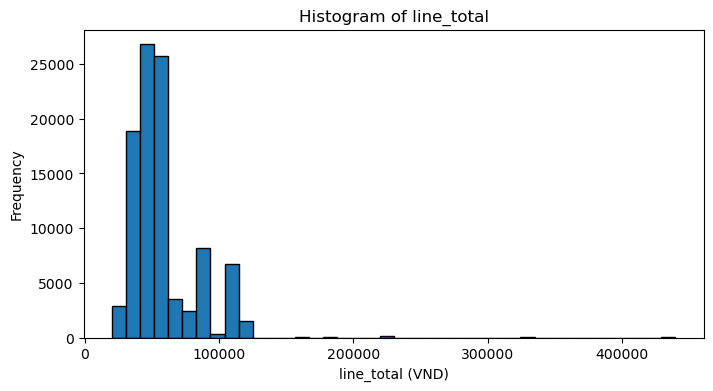

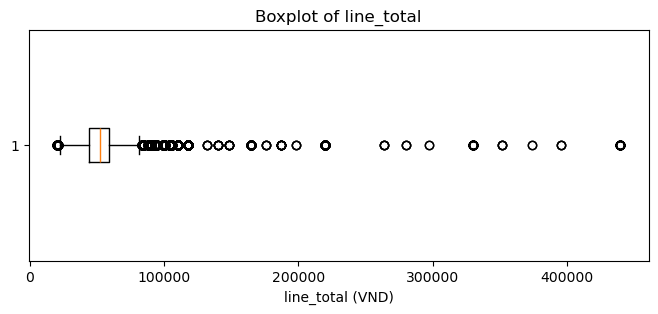

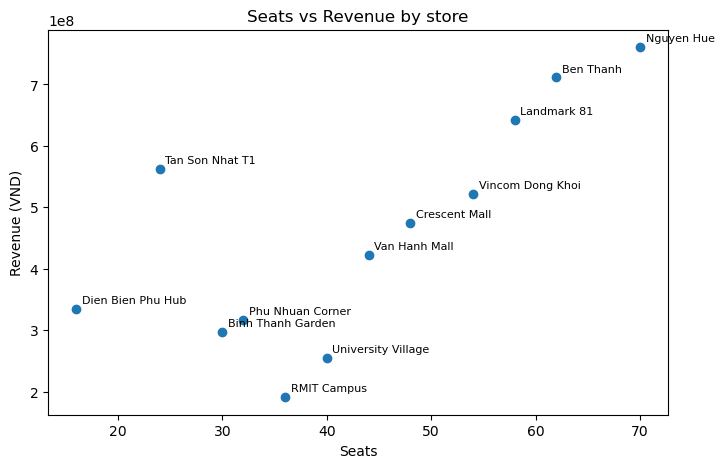

In [13]:
x = clean["line_total"]
q1, q3 = x.quantile(.25), x.quantile(.75)
iqr = q3 - q1

stats = pd.Series({
    "count": x.count(), "mean": x.mean(), "median": x.median(), "mode": x.mode().iloc[0],
    "min": x.min(), "max": x.max(), "range": x.max() - x.min(),
    "variance": x.var(), "std": x.std(),
    "Q1": q1, "Q3": q3, "IQR": iqr,
    "skewness": x.skew(), "kurtosis": x.kurt(),
    "outliers (1.5*IQR)": ((x < q1 - 1.5*iqr) | (x > q3 + 1.5*iqr)).sum()
})
print("=== line_total ===")
print(stats.round(2))

# Thống kê theo cửa hàng (dùng cho scatter seats vs revenue)
store_sum = (clean.groupby(["store_id","store_name","seats"], as_index=False)
                  .agg(revenue=("line_total","sum"), orders=("order_id","nunique")))
display(store_sum)
print(store_sum[["seats","revenue"]].agg(["mean","median","std","min","max"]).round(1))
print("Pearson r :", round(store_sum["seats"].corr(store_sum["revenue"]), 4))
print("Spearman  :", round(store_sum["seats"].corr(store_sum["revenue"], method="spearman"), 4))

# Histogram
plt.figure(figsize=(8,4))
plt.hist(x, bins=40, edgecolor="black")
plt.title("Histogram of line_total"); plt.xlabel("line_total (VND)"); plt.ylabel("Frequency")
plt.show()

# Boxplot
plt.figure(figsize=(8,3))
plt.boxplot(x, vert=False)
plt.title("Boxplot of line_total"); plt.xlabel("line_total (VND)")
plt.show()

# Scatter: seats vs revenue
plt.figure(figsize=(8,5))
plt.scatter(store_sum["seats"], store_sum["revenue"])
for _, r in store_sum.iterrows():
    plt.annotate(r["store_name"], (r["seats"], r["revenue"]), fontsize=8, xytext=(4,4), textcoords="offset points")
plt.title("Seats vs Revenue by store"); plt.xlabel("Seats"); plt.ylabel("Revenue (VND)")
plt.show()

In [14]:
# Vector channel-share của mỗi cửa hàng: tỷ lệ số đơn (order) theo từng kênh
orders = clean.drop_duplicates("order_id")
share = orders.groupby(["store_id","channel"]).size().unstack(fill_value=0)
share = share.div(share.sum(axis=1), axis=0)
share.index = stores.set_index("store_id").loc[share.index, "store_name"]
display(share.round(3))

# Ma trận khoảng cách Euclid 12x12
D = pd.DataFrame(squareform(pdist(share.values, metric="euclidean")),
                 index=share.index, columns=share.index)
print("Shape:", D.shape)
display(D.round(3))

# Cặp gần nhất / xa nhất (chỉ lấy tam giác trên, bỏ đường chéo)
i, j = np.triu_indices(len(D), k=1)
pairs = pd.DataFrame({"store_A": D.index[i], "store_B": D.columns[j], "distance": D.values[i, j]})
pairs = pairs.sort_values("distance").reset_index(drop=True)

print("CLOSEST pair :", pairs.iloc[0].to_dict())
print("FURTHEST pair:", pairs.iloc[-1].to_dict())

channel,app,delivery,in-store
store_name,,,
Nguyen Hue,0.223,0.162,0.615
Ben Thanh,0.225,0.159,0.616
Landmark 81,0.221,0.157,0.622
Vincom Dong Khoi,0.215,0.161,0.624
Crescent Mall,0.220,0.156,0.623
Van Hanh Mall,0.220,0.161,0.620
University Village,0.534,0.094,0.372
RMIT Campus,0.539,0.093,0.368
Phu Nhuan Corner,0.345,0.195,0.459


Shape: (12, 12)


store_name,Nguyen Hue,Ben Thanh,Landmark 81,Vincom Dong Khoi,Crescent Mall,Van Hanh Mall,University Village,RMIT Campus,Phu Nhuan Corner,Binh Thanh Garden,Tan Son Nhat T1,Dien Bien Phu Hub
store_name,,,,,,,,,,,,
Nguyen Hue,0.000,0.004,0.009,0.012,0.011,0.006,0.400,0.407,0.201,0.237,0.372,0.390
Ben Thanh,0.004,0.000,0.007,0.012,0.009,0.006,0.399,0.406,0.201,0.238,0.370,0.389
Landmark 81,0.009,0.007,0.000,0.007,0.002,0.004,0.405,0.411,0.208,0.244,0.364,0.382
Vincom Dong Khoi,0.012,0.012,0.007,0.000,0.007,0.006,0.411,0.418,0.212,0.249,0.361,0.379
Crescent Mall,0.011,0.009,0.002,0.007,0.000,0.006,0.406,0.413,0.210,0.246,0.362,0.380
Van Hanh Mall,0.006,0.006,0.004,0.006,0.006,0.000,0.406,0.412,0.207,0.243,0.366,0.384
University Village,0.400,0.399,0.405,0.411,0.406,0.406,0.000,0.006,0.231,0.205,0.726,0.745
RMIT Campus,0.407,0.406,0.411,0.418,0.413,0.412,0.006,0.000,0.237,0.211,0.733,0.751
Phu Nhuan Corner,0.201,0.201,0.208,0.212,0.210,0.207,0.231,0.237,0.000,0.037,0.568,0.586


CLOSEST pair : {'store_A': 'Landmark 81', 'store_B': 'Crescent Mall', 'distance': 0.0020020778009370442}
FURTHEST pair: {'store_A': 'RMIT Campus', 'store_B': 'Dien Bien Phu Hub', 'distance': 0.7507173463829817}
